1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30


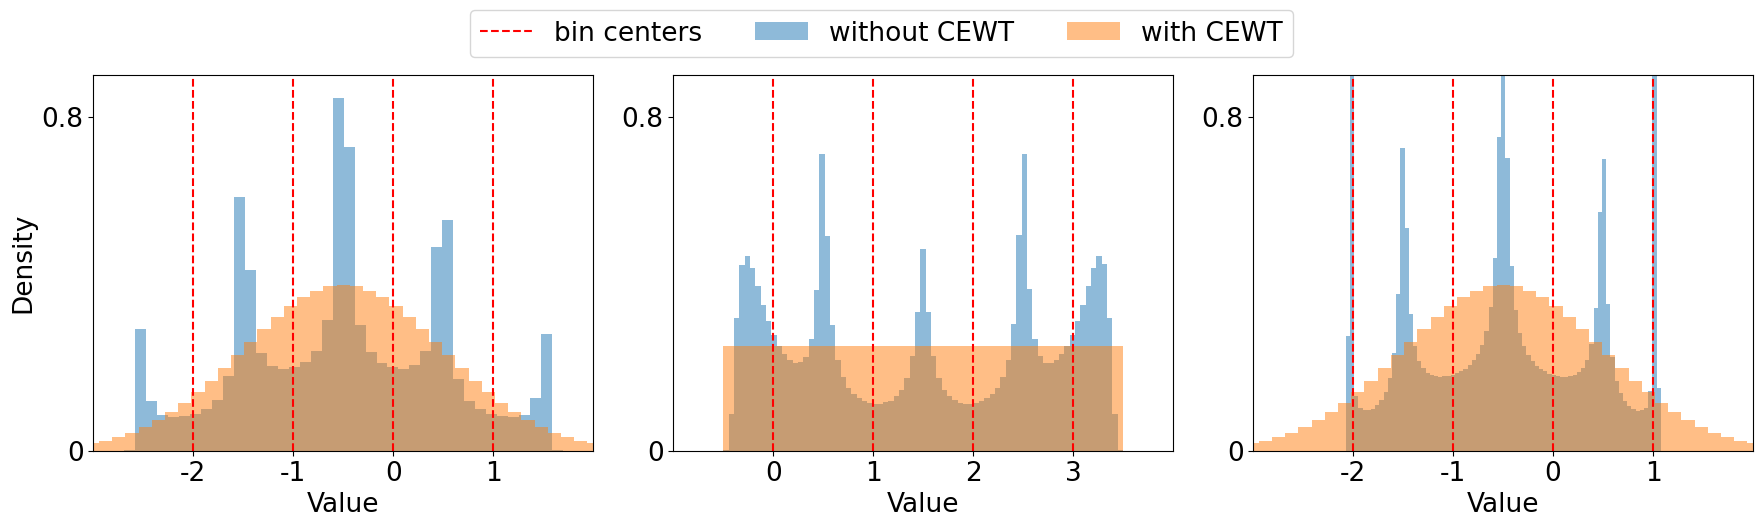

In [1]:
import os, torch, matplotlib.pyplot as plt
from models.quantization.base_linear import OPTIMAL_GAUSSIAN_SCALES, my_hadamard_transform, LSQ
import math
# set figure dpi 
plt.rcParams.update({"font.size": 19})

filename1 = "../exps/v29-llama30M-c4-adamwh-ABBQ-WBBQ-2-constraint-none_c4_llama_nlayers6_nhead5_lr0.0012_sched_cos_warmup1144_decay_linear_0.1_iter11444_bs64x8_ws1_seed0_data_seed1337/ckpts/latest/main.pt"
filename3 = "../exps/v29-llama30M-c4-adamwh-ABBQ-WBBQTGCS-2-constraint-gaussian_c4_llama_nlayers6_nhead5_lr0.0012_sched_cos_warmup1144_decay_linear_0.1_iter11444_bs64x8_ws1_seed0_data_seed1337/ckpts/latest/main.pt"

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for index, (filename, label) in enumerate([(filename1, "without CEWT"), (filename3, "with CEWT")]):
    cp = torch.load(filename, map_location="cpu")
    model = cp["model"]

    data = []
    i = 0
    for k in model.keys():
        if "c_proj" in k or "c_attn" in k or "w1" in k or "w2" in k:
            if k.endswith(".weight"):
                i += 1
                print(i)
                w = model[k]
                x = w
                if index == 0:
                    x = my_hadamard_transform(x, logblocksize=7)
                    rms = x.square().mean(dim=-1, keepdim=True).sqrt() + 1e-8
                    x = 0.5 * (1 + torch.erf((2 ** (-0.5) / rms) * x))
                    x = x * 4 - 0.5
                elif index == 1:
                    rms = x.square().mean().sqrt()
                    x = 0.5 * (1 + torch.erf((2 ** (-0.5) / rms) * x))
                    x = x * 4 - 0.5
                else:
                    assert False, "Invalid index"
                hd = x
                data.append(hd.cpu().flatten())
    
    hd = torch.cat(data, dim=0)
    axs[1].set_yticks([0, 0.8], ["0", "0.8"])
    if index == 0:
        axs[1].vlines(x=[0, 1, 2, 3], ymin=0, ymax=axs[1].get_ylim()[1], colors='red', linestyles='dashed', label="bin centers")
    axs[1].hist(hd.cpu().numpy().flatten(), bins=75, density=True, label=label, alpha=0.5)
    axs[1].set_xlabel("Value")
    axs[1].set_xticks([0, 1, 2, 3], ["0", "1", "2", "3"])
    axs[1].set_ylim(0, 0.9)
    axs[1].set_xlim(-1, 4)


filename1 = "../exps/v29-llama30M-adamwh-AQuESTImproved-WQuESTImproved-2-constraint-none_c4_llama_nlayers6_nhead5_lr0.0012_sched_cos_warmup1144_decay_linear_0.1_iter11444_bs64x8_ws1_seed0_data_seed1337/ckpts/latest/main.pt"
filename3 = "../exps/v29-llama30M-adamwh-AQuESTImproved-WQuESTTGCS-2-constraint-gaussian_c4_llama_nlayers6_nhead5_lr0.0012_sched_cos_warmup1144_decay_linear_0.1_iter11444_bs64x8_ws1_seed0_data_seed1337/ckpts/latest/main.pt"

for index, (filename, label) in enumerate([(filename1, "w.o. CEWT"), (filename3, "with CEWT")]):
    cp = torch.load(filename, map_location="cpu")
    model = cp["model"]

    i = 0
    data = []
    for k in model.keys():
        if "c_proj" in k or "c_attn" in k or "w1" in k or "w2" in k:
            if k.endswith(".weight"):
                i += 1
                print(i)
                w = model[k]
                x = w
                if index == 0:
                    x = my_hadamard_transform(x, 7)
                    std = x.square().mean(dim=-1, keepdim=True).sqrt() # native QuEST detaches std, we do not
                    scale = std * OPTIMAL_GAUSSIAN_SCALES[2] + 1e-8
                    step = scale / (4 - 1) * 2
                    x = x / step - 1 / 2 # most good stuff between -half_n_levels and half_n_levels - 1
                elif index == 1:
                    std = x.square().mean().sqrt() # native QuEST detaches std, we do not
                    scale = std * OPTIMAL_GAUSSIAN_SCALES[2] + 1e-8
                    step = scale / (4 - 1) * 2
                    x = x / step - 1 / 2 # most good stuff between -half_n_levels and half_n_levels - 1
                else:
                    assert False, "Invalid index"
                hd = x
                data.append(hd.cpu().flatten())
    
    hd = torch.cat(data, dim=0)
    axs[0].set_yticks([0, 0.8], ["0", "0.8"])
    if index == 0:
        axs[0].vlines(x=[-2, -1, 0, 1], ymin=0, ymax=axs[0].get_ylim()[1], colors='red', linestyles='dashed')
    axs[0].hist(hd.cpu().numpy().flatten(), bins=75, density=True, alpha=0.5)
    axs[0].set_xlabel("Value")
    axs[0].set_ylabel("Density")
    axs[0].set_xticks([-2, -1, 0, 1], ["-2", "-1", "0", "1"])
    axs[0].set_ylim(0, 0.9)
    axs[0].set_xlim(-3, 2)


filename1 = "../exps/v33-llama30M-adamwh-ALSQ-WLSQ-2-constraint-none_c4_llama_nlayers6_nhead5_lr0.0012_sched_cos_warmup1144_decay_linear_0.1_iter11444_bs64x8_ws1_seed0_data_seed1337/ckpts/latest/main.pt"
filename3 = "../exps/v33-llama30M-adamwh-ALSQ-WLSQ-2-constraint-gaussian_c4_llama_nlayers6_nhead5_lr0.0012_sched_cos_warmup1144_decay_linear_0.1_iter11444_bs64x8_ws1_seed0_data_seed1337/ckpts/latest/main.pt"

for index, (filename, label) in enumerate([(filename1, "w.o. CEWT"), (filename3, "with CEWT")]):
    cp = torch.load(filename, map_location="cpu")
    model = cp["model"]

    i = 0
    data = []
    for k in model.keys():
        if "c_proj" in k or "c_attn" in k or "w1" in k or "w2" in k:
            if k.endswith(".weight"):
                scale = model[k.replace(".weight", ".weight_quantizer.scale")]
                i += 1
                print(i)
                w = model[k]
                x = w
                quantizer = LSQ(bits=2)
                quantizer.scales_initialized = True
                quantizer.scale.data.copy_(scale)
                scale = quantizer.get_scale(x)
                x = x / scale - 1 / 2
                hd = x.detach()
                data.append(hd.cpu().flatten())
    
    hd = torch.cat(data, dim=0)
    axs[2].set_yticks([0, 0.8], ["0", "0.8"])
    if index == 0:
        axs[2].vlines(x=[-2, -1, 0, 1], ymin=0, ymax=axs[2].get_ylim()[1], colors='red', linestyles='dashed')
    axs[2].hist(hd.cpu().numpy().flatten(), bins=75, density=True, alpha=0.5)
    axs[2].set_xlabel("Value")
    axs[2].set_xticks([-2, -1, 0, 1], ["-2", "-1", "0", "1"])
    axs[2].set_ylim(0, 0.9)
    axs[2].set_xlim(-3, 2)
                
fig.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.1))
plt.tight_layout()
fig.savefig("../intro.png", dpi=300, bbox_inches='tight')

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30


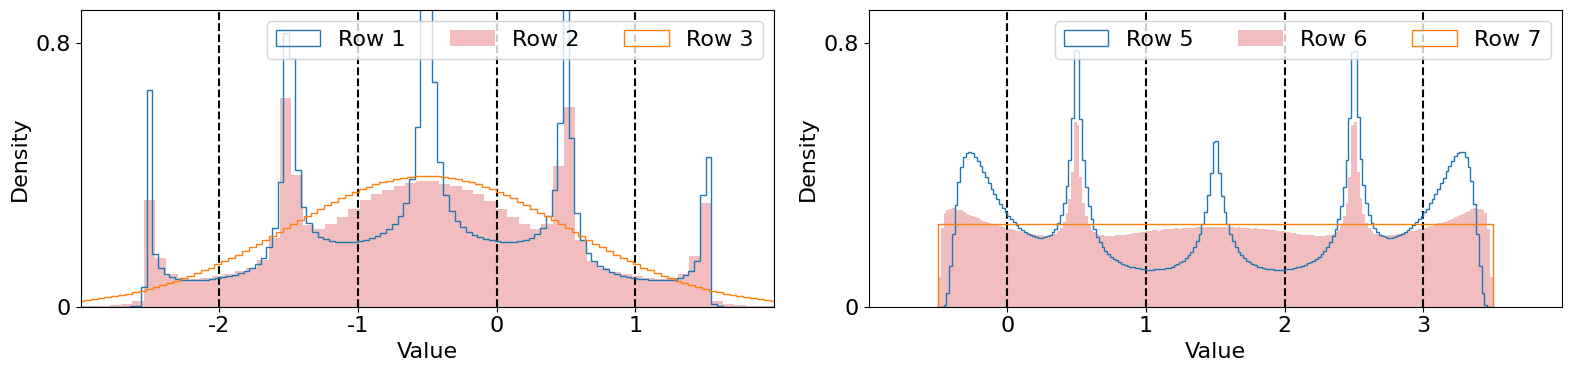

In [2]:
import os, torch, matplotlib.pyplot as plt
from models.quantization.base_linear import OPTIMAL_GAUSSIAN_SCALES, my_hadamard_transform, LSQ
import math
# set figure dpi 
plt.rcParams.update({"font.size": 16})

filename1 = "../exps/v29-llama30M-c4-adamwh-ABBQ-WBBQ-2-constraint-none_c4_llama_nlayers6_nhead5_lr0.0012_sched_cos_warmup1144_decay_linear_0.1_iter11444_bs64x8_ws1_seed0_data_seed1337/ckpts/latest/main.pt"
filename2 = "../exps/v34-llama30M-c4-adamwh-ABBQ-WBBQ-2-constraint-gaussian-qhd0-ohd0_c4_llama_nlayers6_nhead5_lr0.0012_sched_cos_warmup1144_decay_linear_0.1_iter11444_bs64x8_ws1_seed0_data_seed1337/ckpts/latest/main.pt"
filename3 = "../exps/v29-llama30M-c4-adamwh-ABBQ-WBBQTGCS-2-constraint-gaussian_c4_llama_nlayers6_nhead5_lr0.0012_sched_cos_warmup1144_decay_linear_0.1_iter11444_bs64x8_ws1_seed0_data_seed1337/ckpts/latest/main.pt"

fig, axs = plt.subplots(1, 2, figsize=(16, 4))
for index, (filename, label, color) in enumerate([(filename1, "Row 5", "C0"), (filename2, "Row 6", "C3"), (filename3, "Row 7", "C1")]):
    cp = torch.load(filename, map_location="cpu")
    model = cp["model"]

    i = 0
    data = []
    for k in model.keys():
        if "c_proj" in k or "c_attn" in k or "w1" in k or "w2" in k:
            if k.endswith(".weight"):
                i += 1
                print(i)
                w = model[k]
                x = w
                if index == 0:
                    x = my_hadamard_transform(x, logblocksize=7)
                    rms = x.square().mean(dim=-1, keepdim=True).sqrt() + 1e-8
                    x = 0.5 * (1 + torch.erf((2 ** (-0.5) / rms) * x))
                    x = x * 4 - 0.5
                elif index == 1:
                    rms = x.square().mean(dim=-1, keepdim=True).sqrt() + 1e-8
                    x = 0.5 * (1 + torch.erf((2 ** (-0.5) / rms) * x))
                    x = x * 4 - 0.5
                elif index == 2:
                    rms = x.square().mean().sqrt()
                    x = 0.5 * (1 + torch.erf((2 ** (-0.5) / rms) * x))
                    x = x * 4 - 0.5
                else:
                    assert False, "Invalid index"
                hd = x
                data.append(hd.cpu().flatten())
    
    hd = torch.cat(data, dim=0) 
    axs[1].set_yticks([0, 0.8], ["0", "0.8"])
    if index == 0:
        axs[1].vlines(x=[0, 1, 2, 3], ymin=0, ymax=axs[1].get_ylim()[1], colors='black', linestyles='dashed')
    if index != 1:
        axs[1].hist(hd.cpu().numpy().flatten(), bins=200, density=True, label=label, color=color, histtype="step")
    else:
        axs[1].hist(hd.cpu().numpy().flatten(), bins=200, density=True, label=label, color=color, alpha=0.3)
    axs[1].set_xlabel("Value")
    axs[1].set_ylabel("Density")
    axs[1].set_xticks([0, 1, 2, 3], ["0", "1", "2", "3"])
    axs[1].set_ylim(0, 0.9)
    axs[1].set_xlim(-1, 4)
    axs[1].legend(ncols=4)


filename1 = "../exps/v29-llama30M-adamwh-AQuESTImproved-WQuESTImproved-2-constraint-none_c4_llama_nlayers6_nhead5_lr0.0012_sched_cos_warmup1144_decay_linear_0.1_iter11444_bs64x8_ws1_seed0_data_seed1337/ckpts/latest/main.pt"
filename2 = "../exps/v34-llama30M-adamwh-AQuESTImproved-WQuESTImproved-2-constraint-gaussian-qhd0-ohd0_c4_llama_nlayers6_nhead5_lr0.0012_sched_cos_warmup1144_decay_linear_0.1_iter11444_bs64x8_ws1_seed0_data_seed1337/ckpts/latest/main.pt"
filename3 = "../exps/v29-llama30M-adamwh-AQuESTImproved-WQuESTTGCS-2-constraint-gaussian_c4_llama_nlayers6_nhead5_lr0.0012_sched_cos_warmup1144_decay_linear_0.1_iter11444_bs64x8_ws1_seed0_data_seed1337/ckpts/latest/main.pt"


for index, (filename, label, color) in enumerate([(filename1, "Row 1", "C0"), (filename2, "Row 2", "C3"), (filename3, "Row 3", "C1")]):
    cp = torch.load(filename, map_location="cpu")
    model = cp["model"]

    i = 0
    data = []
    for k in model.keys():
        if "c_proj" in k or "c_attn" in k or "w1" in k or "w2" in k:
            if k.endswith(".weight"):
                i += 1
                print(i)
                w = model[k]
                x = w
                if index == 0:
                    x = my_hadamard_transform(x, 7)
                    std = x.square().mean(dim=-1, keepdim=True).sqrt() # native QuEST detaches std, we do not
                    scale = std * OPTIMAL_GAUSSIAN_SCALES[2] + 1e-8
                    step = scale / (4 - 1) * 2
                    x = x / step - 1 / 2 # most good stuff between -half_n_levels and half_n_levels - 1
                elif index == 1:
                    std = x.square().mean(dim=-1, keepdim=True).sqrt() # native QuEST detaches std, we do not
                    scale = std * OPTIMAL_GAUSSIAN_SCALES[2] + 1e-8
                    step = scale / (4 - 1) * 2
                    x = x / step - 1 / 2 # most good stuff between -half_n_levels and half_n_levels - 1
                elif index == 2:
                    std = x.square().mean().sqrt() # native QuEST detaches std, we do not
                    scale = std * OPTIMAL_GAUSSIAN_SCALES[2] + 1e-8
                    step = scale / (4 - 1) * 2
                    x = x / step - 1 / 2 # most good stuff between -half_n_levels and half_n_levels - 1
                else:
                    assert False, "Invalid index"
                hd = x
                data.append(hd.cpu().flatten())
                
    hd = torch.cat(data, dim=0)
    axs[0].set_yticks([0, 0.8], ["0", "0.8"])
    if index == 0:
        axs[0].vlines(x=[-2, -1, 0, 1], ymin=0, ymax=axs[0].get_ylim()[1], colors='black', linestyles='dashed')
    if index != 1:
        axs[0].hist(hd.cpu().numpy().flatten(), bins=200, density=True, color=color, histtype="step", label=label)
    else:
        axs[0].hist(hd.cpu().numpy().flatten(), bins=200, density=True, color=color, alpha=0.3, label=label)
    axs[0].set_xlabel("Value")
    axs[0].set_ylabel("Density")
    axs[0].set_xticks([-2, -1, 0, 1], ["-2", "-1", "0", "1"])
    axs[0].set_ylim(0, 0.9)
    axs[0].set_xlim(-3, 2)
    axs[0].legend(ncols=4)


# # fig.legend(loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.1))0
plt.tight_layout()
fig.savefig("../ablation.png", dpi=300, bbox_inches='tight')